In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración para ver todas las columnas del dataset
pd.set_option('display.max_columns', None)

# Cargar el dataset 
df = pd.read_csv('../data/empleados_ibm.csv')

# Inspección rápida
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
display(df.head())

Filas: 1470 | Columnas: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
cols_a_eliminar = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=cols_a_eliminar, inplace=True)

print(f"Columnas restantes: {df.shape[1]}")

Columnas restantes: 31


In [5]:
df['Attrition_binary'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

tasa_rotacion = df['Attrition_binary'].mean() * 100
print(f"Tasa de rotación general: {tasa_rotacion:.2f}%")

Tasa de rotación general: 16.12%


C:\Users\pardo\AppData\Local\Temp\ipykernel_5884\878487206.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')


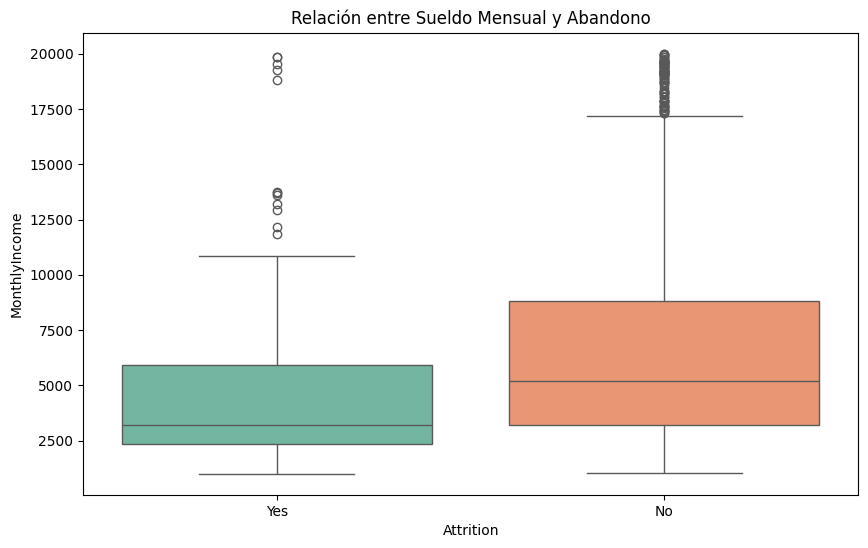

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
plt.title('Relación entre Sueldo Mensual y Abandono')
plt.savefig('../reports/boxplot_sueldos.png')
plt.show()


C:\Users\pardo\AppData\Local\Temp\ipykernel_5884\3079348391.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='Age', palette='magma')


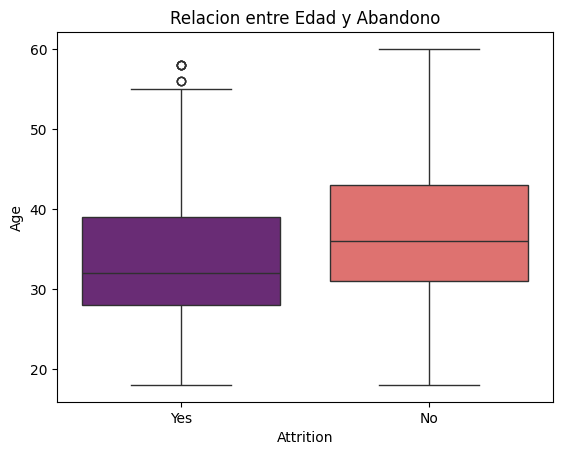

In [7]:
plt.Figure(figsize=(10, 6))
sns.boxplot(data=df, x='Attrition', y='Age', palette='magma')
plt.title('Relacion entre Edad y Abandono')
plt.show()

C:\Users\pardo\AppData\Local\Temp\ipykernel_5884\602397036.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_overtime.index, y=tasa_overtime.values, palette='viridis')


--- RIESGO POR HORAS EXTRA ---
OverTime
No     10.436433
Yes    30.528846
Name: Attrition_binary, dtype: float64


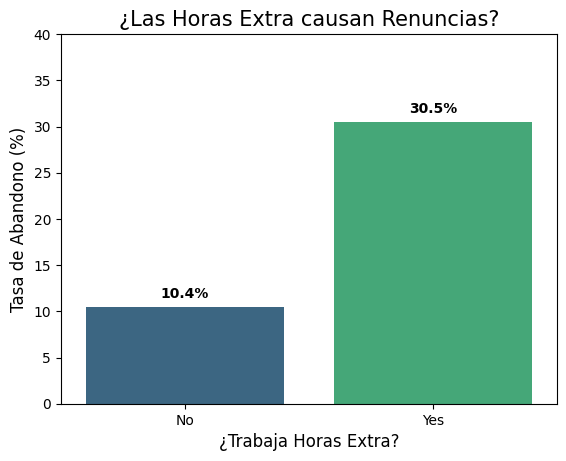

In [8]:
tasa_overtime = df.groupby('OverTime')['Attrition_binary'].mean() * 100

print("--- RIESGO POR HORAS EXTRA ---")
print(tasa_overtime)

plt.Figure(figsize=(8, 5))
sns.barplot(x=tasa_overtime.index, y=tasa_overtime.values, palette='viridis')

plt.ylim(0, 40)
plt.title('¿Las Horas Extra causan Renuncias?', fontsize=15)
plt.ylabel('Tasa de Abandono (%)', fontsize=12)
plt.xlabel('¿Trabaja Horas Extra?', fontsize=12)

for i, v in enumerate(tasa_overtime.values):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.show()    

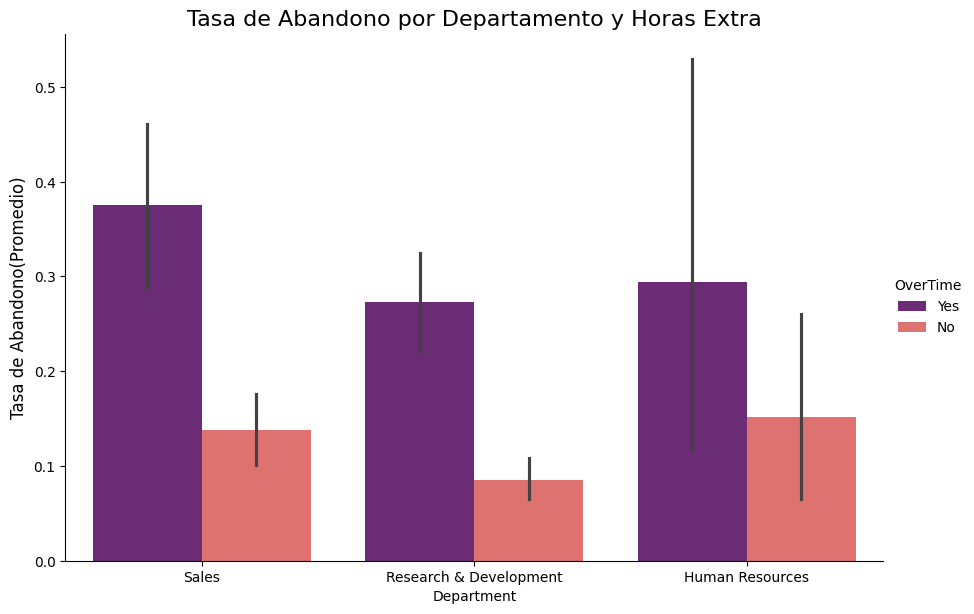

In [13]:
g= sns.catplot(
    data=df,
    x='Department',
    y='Attrition_binary',
    hue='OverTime',
    kind='bar',
    palette='magma',
    height=6,
    aspect=1.5
)

plt.title('Tasa de Abandono por Departamento y Horas Extra', fontsize=16)
plt.ylabel('Tasa de Abandono(Promedio)', fontsize=12)
g.savefig('../reports/barras_departamento_ot.png')
plt.show()